<a href="https://colab.research.google.com/github/kimhj5125/speaker-recognition/blob/main/Speaker_Recognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install noisereduce

In [2]:
# ============================================================
# [셀 0] 공통 설정: Import / 상수 / 함수 정의
# ============================================================

# ── Imports ──────────────────────────────────────────────────
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import noisereduce as nr
import kagglehub

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from sklearn.inspection import permutation_importance

# ── 상수 ─────────────────────────────────────────────────────
SR            = 16000
N_MFCC        = 20
DRIVE_DIR     = "/content/drive/MyDrive/Speech_Project"
NOISE_FOLDERS = ['_background_noise_', 'other']
SPEAKER_NAMES = [
    "Benjamin_Netanyau",
    "Jens_Stoltenberg",
    "Julia_Gillard",
    "Margaret_Tatcher",
    "Nelson_Mandela",
]

# ── 공통 함수 정의 ─────────────────────────────────────────────────
drive.mount('/content/drive')

def extract_features(audio_data, sr=SR, n_mfcc=N_MFCC):
    """
    오디오 배열에서 25차원 특징 벡터를 추출.
      - MFCC       : n_mfcc개 (기본 20)
      - Spectral   : Centroid, Rolloff, Bandwidth (각 1)
      - Pitch (f0) : 1
      - Energy(RMS): 1
    """
    features = []
    for i, signal in enumerate(audio_data):
        vec = []

        # MFCC (20차원)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
        vec.extend(np.mean(mfcc, axis=1))

        # Spectral features (3차원)
        vec.append(np.mean(librosa.feature.spectral_centroid(y=signal, sr=sr)))
        vec.append(np.mean(librosa.feature.spectral_rolloff(y=signal, sr=sr)))
        vec.append(np.mean(librosa.feature.spectral_bandwidth(y=signal, sr=sr)))

        # Pitch / f0 (1차원)
        f0, _, _ = librosa.pyin(signal,
                                 fmin=librosa.note_to_hz('C2'),
                                 fmax=librosa.note_to_hz('C7'),
                                 sr=sr)
        vec.append(np.nanmean(f0) if not np.all(np.isnan(f0)) else 0.0)

        # RMS Energy (1차원)
        vec.append(np.mean(librosa.feature.rms(y=signal)))

        features.append(vec)

        if (i + 1) % 500 == 0 or (i + 1) == len(audio_data):
            print(f"  └ 진행: {i+1}/{len(audio_data)}")

    return np.array(features)


def save_npy(data_dict, save_dir=DRIVE_DIR):
    """딕셔너리 {파일명: 배열} 을 Drive에 일괄 저장."""
    os.makedirs(save_dir, exist_ok=True)
    for name, arr in data_dict.items():
        np.save(os.path.join(save_dir, f"{name}.npy"), arr)
    print(f"💾 저장 완료 → {save_dir}")


def load_npy(*names, load_dir=DRIVE_DIR):
    """Drive에서 .npy 파일들을 순서대로 로드하여 반환."""
    return [np.load(os.path.join(load_dir, f"{n}.npy")) for n in names]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ============================================================
# [셀 1] 데이터 로드
# ============================================================

path = kagglehub.dataset_download("kongaevans/speaker-recognition-dataset")

# kagglehub 버전 폴더 구조 대응 — 실제 데이터 루트 탐색
if not os.path.exists(os.path.join(path, SPEAKER_NAMES[0])):
    path = [f.path for f in os.scandir(path) if f.is_dir()][0]
actual_path = path

print(f"📂 데이터 경로 : {actual_path}")
print(f"📁 내부 폴더   : {os.listdir(actual_path)}")

Using Colab cache for faster access to the 'speaker-recognition-dataset' dataset.
📂 데이터 경로 : /kaggle/input/speaker-recognition-dataset/16000_pcm_speeches
📁 내부 폴더   : ['Nelson_Mandela', 'Benjamin_Netanyau', 'other', '_background_noise_', 'tf_Wav_reader.py', 'Magaret_Tarcher', 'Jens_Stoltenberg', 'Julia_Gillard']


In [4]:
# ============================================================
# [셀 2] EDA — 화자/노이즈 데이터 규격 진단
# ============================================================

all_folders = os.listdir(actual_path)
target_speakers = [
    f for f in all_folders
    if os.path.isdir(os.path.join(actual_path, f)) and f not in NOISE_FOLDERS
]

rows = []
for folder in target_speakers + NOISE_FOLDERS:
    full_path = os.path.join(actual_path, folder)
    if not os.path.exists(full_path):
        fallback = glob.glob(os.path.join(actual_path, "**", folder), recursive=True)
        if fallback:
            full_path = fallback[0]
        else:
            continue

    wav_files = glob.glob(os.path.join(full_path, "**/*.wav"), recursive=True)
    durations = []
    for f in wav_files:
        try:
            durations.append(librosa.get_duration(path=f))
        except Exception:
            pass

    if durations:
        min_d, max_d = min(durations), max(durations)
        status = "Perfect (1.0s)" if (round(min_d, 2) == 1.0 and round(max_d, 2) == 1.0) else "Variable"
    else:
        min_d = max_d = 0
        status = "No Data"

    rows.append({
        "Folder / Speaker"      : folder,
        "Type"                  : "Noise/Other" if folder in NOISE_FOLDERS else "Target Speaker",
        "File Count"            : len(wav_files),
        "Min Duration (s)"      : round(min_d, 2),
        "Max Duration (s)"      : round(max_d, 2),
        "Status (All 1.0 s?)"   : status,
    })

df_meta = pd.DataFrame(rows)
display(df_meta)
# → 5명의 화자가 각 1초짜리 wav 파일 약 1,500개씩 보유하고 있음을 확인

,Folder / Speaker,Type,File Count,Min Duration (s),Max Duration (s),Status (All 1.0 s?)
0,Nelson_Mandela,Target Speaker,1500,1.00,1.00,Perfect (1.0s)
1,Benjamin_Netanyau,Target Speaker,1500,1.00,1.00,Perfect (1.0s)
2,Magaret_Tarcher,Target Speaker,1500,1.00,1.00,Perfect (1.0s)
3,Jens_Stoltenberg,Target Speaker,1500,1.00,1.00,Perfect (1.0s)
4,Julia_Gillard,Target Speaker,1501,1.00,1.00,Perfect (1.0s)
5,_background_noise_,Noise/Other,4,16.29,95.18,Variable
6,other,Noise/Other,2,60.00,61.25,Variable


In [5]:
# ============================================================
# [셀 3] 데이터 전처리 — 노이즈 제거 & 분할 & Drive 저장
# ============================================================
# 데이터 분할 비율: Train 60% / Validation 20% / Test 20%
# 참고: Xu et al. (2018), "Speaker Recognition Using Deep Neural Networks"
#       — 학습 데이터 충분성 확보를 위해 6:2:2 분할이 일반적으로 사용됨.

# 노이즈 프로파일 구축
noise_samples = []
for folder in NOISE_FOLDERS:
    folder_path = os.path.join(actual_path, folder)
    if not os.path.exists(folder_path):
        continue
    for f in glob.glob(os.path.join(folder_path, "**/*.wav"), recursive=True):
        try:
            y, _ = librosa.load(f, sr=SR, duration=10.0)
            noise_samples.append(y)
        except Exception:
            pass

if noise_samples:
    combined_noise = np.concatenate(noise_samples)
    print(f"✅ 노이즈 프로파일 구축 완료 (총 {len(combined_noise)/SR:.2f}초)")
else:
    combined_noise = None
    print("⚠️ 노이즈 파일 없음 — 소음 차감 없이 진행합니다.")

# 전체 오디오 로드 + 노이즈 제거
# 전체 오디오 로드 + 노이즈 제거 (인라인)
print("\n⚡ 오디오 전처리 시작...")
audio_signals, labels = [], []
for label_idx, speaker in enumerate(target_speakers):
    speaker_path = os.path.join(actual_path, speaker)
    wav_files = glob.glob(os.path.join(speaker_path, "*.wav"))
    print(f"  [{speaker}] 노이즈 제거 중... ({len(wav_files)}개)")
    for f in wav_files:
        try:
            y, _ = librosa.load(f, sr=SR, duration=1.0)
            if len(y) < SR:
                y = librosa.util.fix_length(y, size=SR)
            if combined_noise is not None:
                y = nr.reduce_noise(y=y, sr=SR, y_noise=combined_noise,
                                    stationary=True, n_jobs=1)
            audio_signals.append(y)
            labels.append(label_idx)
        except Exception as e:
            print(f"    ⚠️ 제외: {f} → {e}")

X_audio = np.array(audio_signals)
y_audio = np.array(labels)
print(f"\n✅ 전처리 완료: {X_audio.shape}")

# Train(60%) / Val(20%) / Test(20%) 분할
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_audio, y_audio, test_size=0.20, random_state=42, stratify=y_audio
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"\n📊 데이터 분할 결과:")
print(f"  Train      (60%) : {X_train.shape}")
print(f"  Validation (20%) : {X_val.shape}")
print(f"  Test       (20%) : {X_test.shape}")

# Drive 저장
save_npy({
    "X_train": X_train, "y_train": y_train,
    "X_val"  : X_val,   "y_val"  : y_val,
    "X_test" : X_test,  "y_test" : y_test,
})

✅ 노이즈 프로파일 구축 완료 (총 60.00초)

⚡ 오디오 전처리 시작...
  [Nelson_Mandela] 노이즈 제거 중... (1500개)
  [Benjamin_Netanyau] 노이즈 제거 중... (1500개)
  [Magaret_Tarcher] 노이즈 제거 중... (1500개)
  [Jens_Stoltenberg] 노이즈 제거 중... (1500개)
  [Julia_Gillard] 노이즈 제거 중... (1501개)

✅ 전처리 완료: (7501, 16000)

📊 데이터 분할 결과:
  Train      (60%) : (4500, 16000)
  Validation (20%) : (1500, 16000)
  Test       (20%) : (1501, 16000)
💾 저장 완료 → /content/drive/MyDrive/Speech_Project


In [6]:
# ============================================================
# [셀 4] Train — 특징 추출 & Scaling
# ============================================================

X_train_raw, y_train = load_npy("X_train", "y_train")

print("⚡ Train 특징 추출 중...")
X_train_features = extract_features(X_train_raw)

# Scaler는 Train 기준으로만 fit
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)

save_npy({"X_train_features": X_train_features, "X_train_scaled": X_train_scaled})
print(f"✅ Train 특징 추출 완료: {X_train_features.shape}  (25차원)")

⚡ Train 특징 추출 중...
  └ 진행: 500/4500
  └ 진행: 1000/4500
  └ 진행: 1500/4500
  └ 진행: 2000/4500
  └ 진행: 2500/4500
  └ 진행: 3000/4500
  └ 진행: 3500/4500
  └ 진행: 4000/4500
  └ 진행: 4500/4500
💾 저장 완료 → /content/drive/MyDrive/Speech_Project
✅ Train 특징 추출 완료: (4500, 25)  (25차원)


In [7]:
# ============================================================
# [셀 5] Train — 모델 학습 (RF / Linear SVM / RBF SVM)
# ============================================================

X_train_features, X_train_scaled, y_train = load_npy("X_train_features", "X_train_scaled", "y_train")

# Random Forest
print("[Model 1] Random Forest 학습 중...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_features, y_train)      # RF는 스케일 불필요 — raw feature 사용
print("  → 완료")

# Linear SVM
print("[Model 2] Linear SVM 학습 중...")
linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_train_scaled, y_train)
print("  → 완료")

# RBF SVM (임시 파라미터 — Val 단계에서 최적값으로 교체됨)
print("[Model 3] RBF SVM 학습 중 (C=1.0, gamma='scale' — 임시)...")
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
rbf_svm.fit(X_train_scaled, y_train)
print("  → 완료")

[Model 1] Random Forest 학습 중...
  → 완료
[Model 2] Linear SVM 학습 중...
  → 완료
[Model 3] RBF SVM 학습 중 (C=1.0, gamma='scale' — 임시)...
  → 완료


In [8]:
# ============================================================
# [셀 6] Validation — 특징 추출 & Scaling
# ============================================================

X_val_raw, y_val = load_npy("X_val", "y_val")

print("⚡ Validation 특징 추출 중...")
X_val_features = extract_features(X_val_raw)

# Train에서 fit된 scaler로 transform만
X_val_scaled = scaler.transform(X_val_features)

save_npy({"X_val_features": X_val_features, "X_val_scaled": X_val_scaled})
print(f"✅ Validation 특징 추출 완료: {X_val_features.shape}")

⚡ Validation 특징 추출 중...
  └ 진행: 500/1500
  └ 진행: 1000/1500
  └ 진행: 1500/1500
💾 저장 완료 → /content/drive/MyDrive/Speech_Project
✅ Validation 특징 추출 완료: (1500, 25)


In [9]:
# ============================================================
# [셀 7] Validation — Grid Search (RBF SVM 최적 C & gamma 탐색)
# ============================================================

X_val_scaled, y_val     = load_npy("X_val_scaled", "y_val")
X_train_scaled, y_train = load_npy("X_train_scaled", "y_train")

C_list     = [0.1, 1, 10, 100]
gamma_list = [0.001, 0.01, 0.1, 1]

best_val_acc = 0.0
best_C = best_gamma = None
cnt = 0

print(f"{'#':^4} | {'C':^6} | {'gamma':^8} | {'Val Acc':^10}")
print("-" * 38)

for C in C_list:
    for gamma in gamma_list:
        cnt += 1
        m = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        m.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_val, m.predict(X_val_scaled))
        print(f"{cnt:^4} | {C:^6} | {gamma:^8} | {acc*100:>8.2f}%")
        if acc > best_val_acc:
            best_val_acc, best_C, best_gamma = acc, C, gamma

print(f"\n🎯 최적 C={best_C}, gamma={best_gamma}  →  Val Acc: {best_val_acc*100:.2f}%")

# 최적 파라미터로 최종 RBF SVM 재학습
best_rbf_svm = SVC(kernel='rbf', C=best_C, gamma=best_gamma, random_state=42)
best_rbf_svm.fit(X_train_scaled, y_train)
print("🚀 최종 RBF SVM 학습 완료")

 #   |   C    |  gamma   |  Val Acc  
--------------------------------------
 1   |  0.1   |  0.001   |    83.80%
 2   |  0.1   |   0.01   |    94.93%
 3   |  0.1   |   0.1    |    97.67%
 4   |  0.1   |    1     |    31.80%
 5   |   1    |  0.001   |    94.80%
 6   |   1    |   0.01   |    97.73%
 7   |   1    |   0.1    |    98.87%
 8   |   1    |    1     |    50.07%
 9   |   10   |  0.001   |    97.00%
 10  |   10   |   0.01   |    98.33%
 11  |   10   |   0.1    |    99.07%
 12  |   10   |    1     |    52.67%
 13  |  100   |  0.001   |    97.87%
 14  |  100   |   0.01   |    98.67%
 15  |  100   |   0.1    |    99.20%
 16  |  100   |    1     |    52.67%

🎯 최적 C=100, gamma=0.1  →  Val Acc: 99.20%
🚀 최종 RBF SVM 학습 완료


In [10]:
# ============================================================
# [셀 8] Validation — 모델 성능 비교
# ============================================================

X_val_features, X_val_scaled, y_val = load_npy("X_val_features", "X_val_scaled", "y_val")

rf_acc     = accuracy_score(y_val, rf.predict(X_val_features))
linear_acc = linear_svm.score(X_val_scaled, y_val)
rbf_acc    = best_rbf_svm.score(X_val_scaled, y_val)

print("=" * 55)
print("📊 Validation Set 모델 성능 비교")
print("=" * 55)
print(f"  Random Forest                     : {rf_acc*100:.2f}%")
print(f"  Linear SVM                        : {linear_acc*100:.2f}%")
print(f"  RBF SVM (C={best_C}, γ={best_gamma}) : {rbf_acc*100:.2f}%")
print("=" * 55)
# 💡 [해석] 추출된 오디오 특징(Feature)이 고차원 공간에서 이미 화자 특성을
# 훌륭하게 표현하고 있어(선형 분리가 가능한 수준), 모델의 종류(선형/비선형)에
# 관계없이 모두 유의미하게 높은 성능을 보임. 이에 따라 세 모델 모두 Test 단계에서 검증 진행.

📊 Validation Set 모델 성능 비교
  Random Forest                     : 97.53%
  Linear SVM                        : 97.60%
  RBF SVM (C=100, γ=0.1) : 99.20%


In [11]:
# ============================================================
# [셀 9] Test — 특징 추출 & Scaling
# ============================================================

X_test_raw, y_test = load_npy("X_test", "y_test")

print("⚡ Test 특징 추출 중...")
X_test_features = extract_features(X_test_raw)

# ⚠️ 매우 중요: Train 세트 기준의 scaler를 그대로 사용하여 'transform'만 수행
X_test_scaled = scaler.transform(X_test_features)

save_npy({"X_test_features": X_test_features, "X_test_scaled": X_test_scaled})
print(f"✅ Test 특징 추출 완료: {X_test_features.shape}")

⚡ Test 특징 추출 중...
  └ 진행: 500/1501
  └ 진행: 1000/1501
  └ 진행: 1500/1501
  └ 진행: 1501/1501
💾 저장 완료 → /content/drive/MyDrive/Speech_Project
✅ Test 특징 추출 완료: (1501, 25)


In [12]:
# ============================================================
# [셀 10] Test ML
# ============================================================
X_train_features, X_train_scaled, y_train = load_npy("X_train_features", "X_train_scaled", "y_train")

# Random Forest
print("[Model 1] Random Forest 학습 중...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_features, y_train)      # RF는 스케일 불필요 — raw feature 사용
print("  → 완료")

# Linear SVM
print("[Model 2] Linear SVM 학습 중...")
linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_train_scaled, y_train)
print("  → 완료")

# RBF SVM (Val 단계에서 최적화된 파라미터 적용)
print("[Model 3] RBF SVM 학습 중 (C=10, gamma=0.1)...")
rbf_svm = SVC(kernel='rbf', C=10, gamma=0.1, random_state=42)
rbf_svm.fit(X_train_scaled, y_train)
print("  → 완료")

[Model 1] Random Forest 학습 중...
  → 완료
[Model 2] Linear SVM 학습 중...
  → 완료
[Model 3] RBF SVM 학습 중 (C=10, gamma=0.1)...
  → 완료


📊 Test Set Accuracy
RF         Accuracy : 97.27%
Linear SVM Accuracy : 97.47%
RBF SVM    Accuracy : 98.93%

📊 RF Classification Report
                   precision    recall  f1-score   support

Benjamin_Netanyau       1.00      1.00      1.00       300
 Jens_Stoltenberg       0.95      0.95      0.95       300
    Julia_Gillard       0.95      0.98      0.97       300
 Margaret_Tatcher       0.98      0.96      0.97       300
   Nelson_Mandela       0.99      0.97      0.98       301

         accuracy                           0.97      1501
        macro avg       0.97      0.97      0.97      1501
     weighted avg       0.97      0.97      0.97      1501


📊 Linear SVM Classification Report
                   precision    recall  f1-score   support

Benjamin_Netanyau       1.00      1.00      1.00       300
 Jens_Stoltenberg       0.95      0.93      0.94       300
    Julia_Gillard       0.94      0.96      0.95       300
 Margaret_Tatcher       0.98      0.99      0.98       300

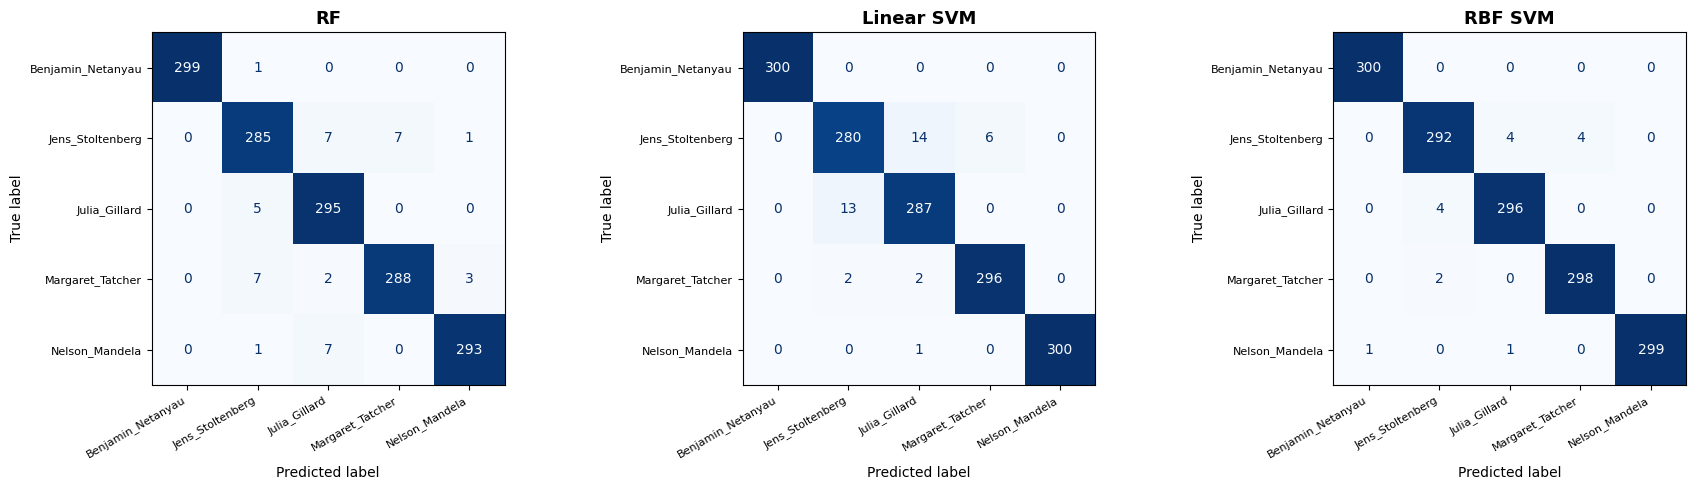

✅ Confusion Matrix 저장 완료


In [13]:
# ============================================================
# [셀 11] 평가 — Accuracy / Confusion Matrix / F1-score
# ============================================================

# ── 예측 ──────────────────────────────────────────────────────
y_pred_rf         = rf.predict(X_test_features)
y_pred_linear_svm = linear_svm.predict(X_test_scaled)
y_pred_rbf_svm    = rbf_svm.predict(X_test_scaled)

# ── Accuracy ─────────────────────────────────────────────────
print("📊 Test Set Accuracy")
print(f"RF         Accuracy : {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"Linear SVM Accuracy : {accuracy_score(y_test, y_pred_linear_svm) * 100:.2f}%")
print(f"RBF SVM    Accuracy : {accuracy_score(y_test, y_pred_rbf_svm) * 100:.2f}%")

# ── Classification Report (F1-score) ─────────────────────────
for name, y_pred in [("RF", y_pred_rf), ("Linear SVM", y_pred_linear_svm), ("RBF SVM", y_pred_rbf_svm)]:
    print(f"\n📊 {name} Classification Report")
    print(classification_report(y_test, y_pred, target_names=SPEAKER_NAMES))

# ── Confusion Matrix ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, y_pred in zip(axes,
                             ["RF", "Linear SVM", "RBF SVM"],
                             [y_pred_rf, y_pred_linear_svm, y_pred_rbf_svm]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=SPEAKER_NAMES
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xticklabels(SPEAKER_NAMES, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(SPEAKER_NAMES, fontsize=8)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion Matrix 저장 완료")

⚡ Linear SVM Permutation Importance 계산 중...
⚡ RBF SVM Permutation Importance 계산 중...


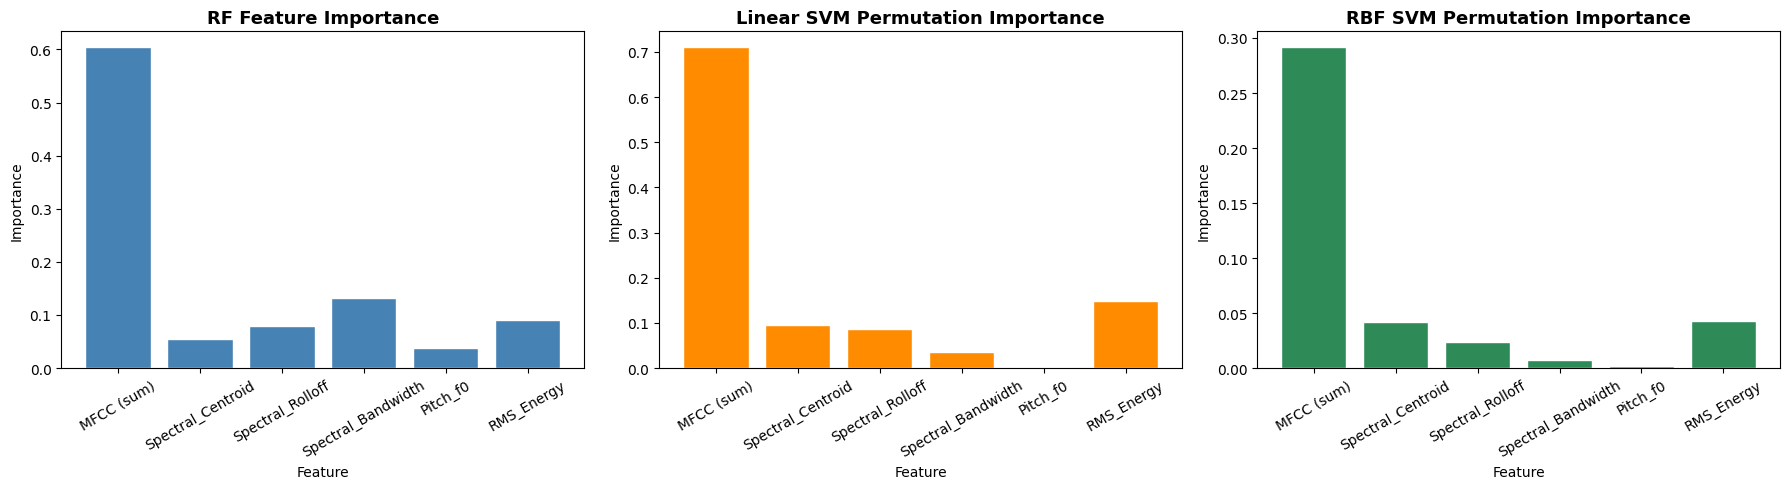

✅ Feature Importance 저장 완료

⚡ t-SNE 시각화 중...


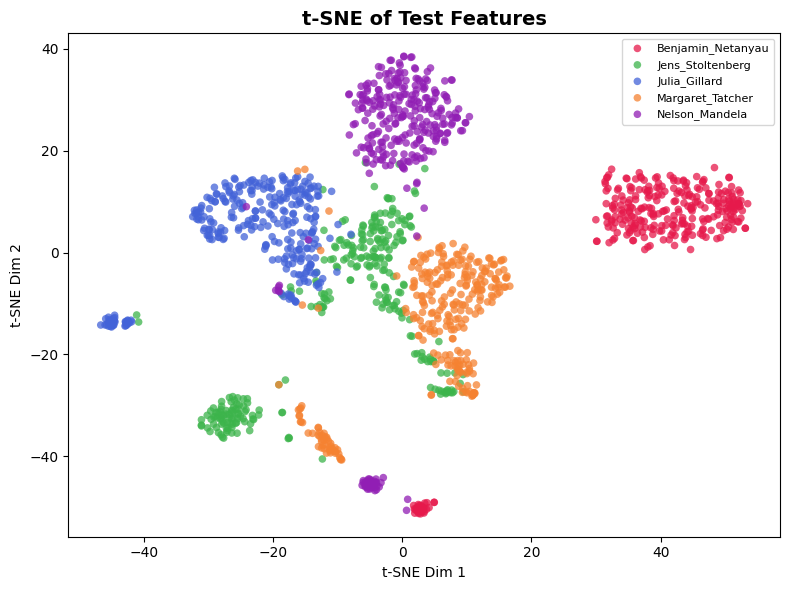

✅ t-SNE 저장 완료


In [14]:
# ============================================================
# [셀 12] 분석 — Feature Importance / t-SNE
# ============================================================

# ── Feature Labels (25차원) ───────────────────────────────────
feature_labels = (
    [f"MFCC_{i}" for i in range(N_MFCC)]   # 0~19
    + ["Spectral_Centroid", "Spectral_Rolloff", "Spectral_Bandwidth"]  # 20~22
    + ["Pitch_f0"]                           # 23
    + ["RMS_Energy"]                         # 24
)

MFCC_IDX      = list(range(N_MFCC))         # 0~19
NON_MFCC_IDX  = list(range(N_MFCC, 25))     # 20~24
non_mfcc_labels = feature_labels[N_MFCC:]

def plot_importance(ax, importances, title, color):
    """MFCC는 합산, 나머지는 개별 표시."""
    mfcc_sum   = importances[MFCC_IDX].sum()
    non_mfcc   = importances[NON_MFCC_IDX]
    values     = [mfcc_sum] + list(non_mfcc)
    labels     = ["MFCC (sum)"] + non_mfcc_labels

    ax.bar(labels, values, color=color, edgecolor="white")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Importance")
    ax.tick_params(axis="x", rotation=30)

# ── Feature Importance ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# [1] RF — built-in importance
plot_importance(axes[0], rf.feature_importances_, "RF Feature Importance", "steelblue")

# [2] Linear SVM — permutation importance
print("⚡ Linear SVM Permutation Importance 계산 중...")
perm_linear = permutation_importance(
    linear_svm, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
plot_importance(axes[1], perm_linear.importances_mean, "Linear SVM Permutation Importance", "darkorange")

# [3] RBF SVM — permutation importance
print("⚡ RBF SVM Permutation Importance 계산 중...")
perm_rbf = permutation_importance(
    rbf_svm, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
plot_importance(axes[2], perm_rbf.importances_mean, "RBF SVM Permutation Importance", "seagreen")

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/feature_importance.png", dpi=150)
plt.show()
print("✅ Feature Importance 저장 완료\n")

# ── t-SNE ─────────────────────────────────────────────────────
print("⚡ t-SNE 시각화 중...")

PALETTE = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4"]

tsne   = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for idx, name in enumerate(SPEAKER_NAMES):
    mask = y_test == idx
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        label=name, color=PALETTE[idx],
        s=30, alpha=0.75, edgecolors="none"
    )
ax.set_title("t-SNE of Test Features", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE Dim 1")
ax.set_ylabel("t-SNE Dim 2")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/tsne.png", dpi=150)
plt.show()
print("✅ t-SNE 저장 완료")